In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [22]:
df = pd.read_csv('../DataSet/ml_ready_data.csv')

In [23]:
df.drop(columns=['Seniority'], inplace=True)

In [24]:
df

,Job_Title,Industry,Job_Status,AI_Impact_Level,Median_Salary_(USD),Required_Education,Experience_Required_(Years),Job_Openings_(2024),Projected_Openings_(2030),Remote_Work_Ratio,Automation_Risk,Location,Gender_Diversity,Growth_Rate,Risk_Category,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Is_High_Risk
0,3,3,0,0,0.397944,4,-0.846500,0.484342,-1.203914,-0.495603,-1.479939,4,-1.510780,-0.344427,1,-0.438781,-1.071137,0.829182,1
1,3,3,0,0,0.397944,4,-0.846500,0.484342,-1.203914,-0.495603,-1.479939,4,-1.510780,-0.344427,1,-1.244947,-1.454739,0.479884,1
2,3,3,0,0,0.397944,4,-0.846500,0.484342,-1.203914,-0.495603,-1.479939,4,-1.510780,-0.344427,1,0.332335,-1.106010,1.702427,1
3,3,3,0,0,0.397944,4,-0.846500,0.484342,-1.203914,-0.495603,-1.479939,4,-1.510780,-0.344427,1,-0.684136,-1.629104,-1.266606,1
4,3,3,0,0,0.397944,4,-0.846500,0.484342,-1.203914,-0.495603,-1.479939,4,-1.510780,-0.344427,1,-1.595454,0.637635,0.217910,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28624,3,2,0,2,-1.344789,1,-1.182108,-0.615865,-1.608389,-1.704488,0.849130,2,1.191724,-0.362334,0,0.577690,0.463270,-1.441255,0
28625,3,2,0,2,-1.344789,1,-1.182108,-0.615865,-1.608389,-1.704488,0.849130,2,1.191724,-0.362334,0,-1.069694,-1.350121,-0.829984,0
28626,3,2,0,2,-1.344789,1,-1.182108,-0.615865,-1.608389,-1.704488,0.849130,2,1.191724,-0.362334,0,0.437487,-1.245502,-1.703229,0
28627,3,2,0,2,-1.344789,1,-1.182108,-0.615865,-1.608389,-1.704488,0.849130,2,1.191724,-0.362334,0,-1.595454,0.602762,0.916506,0


In [25]:
df['AI_Impact_Level'].value_counts()

AI_Impact_Level
1    12547
0     9691
2     6391
Name: count, dtype: int64

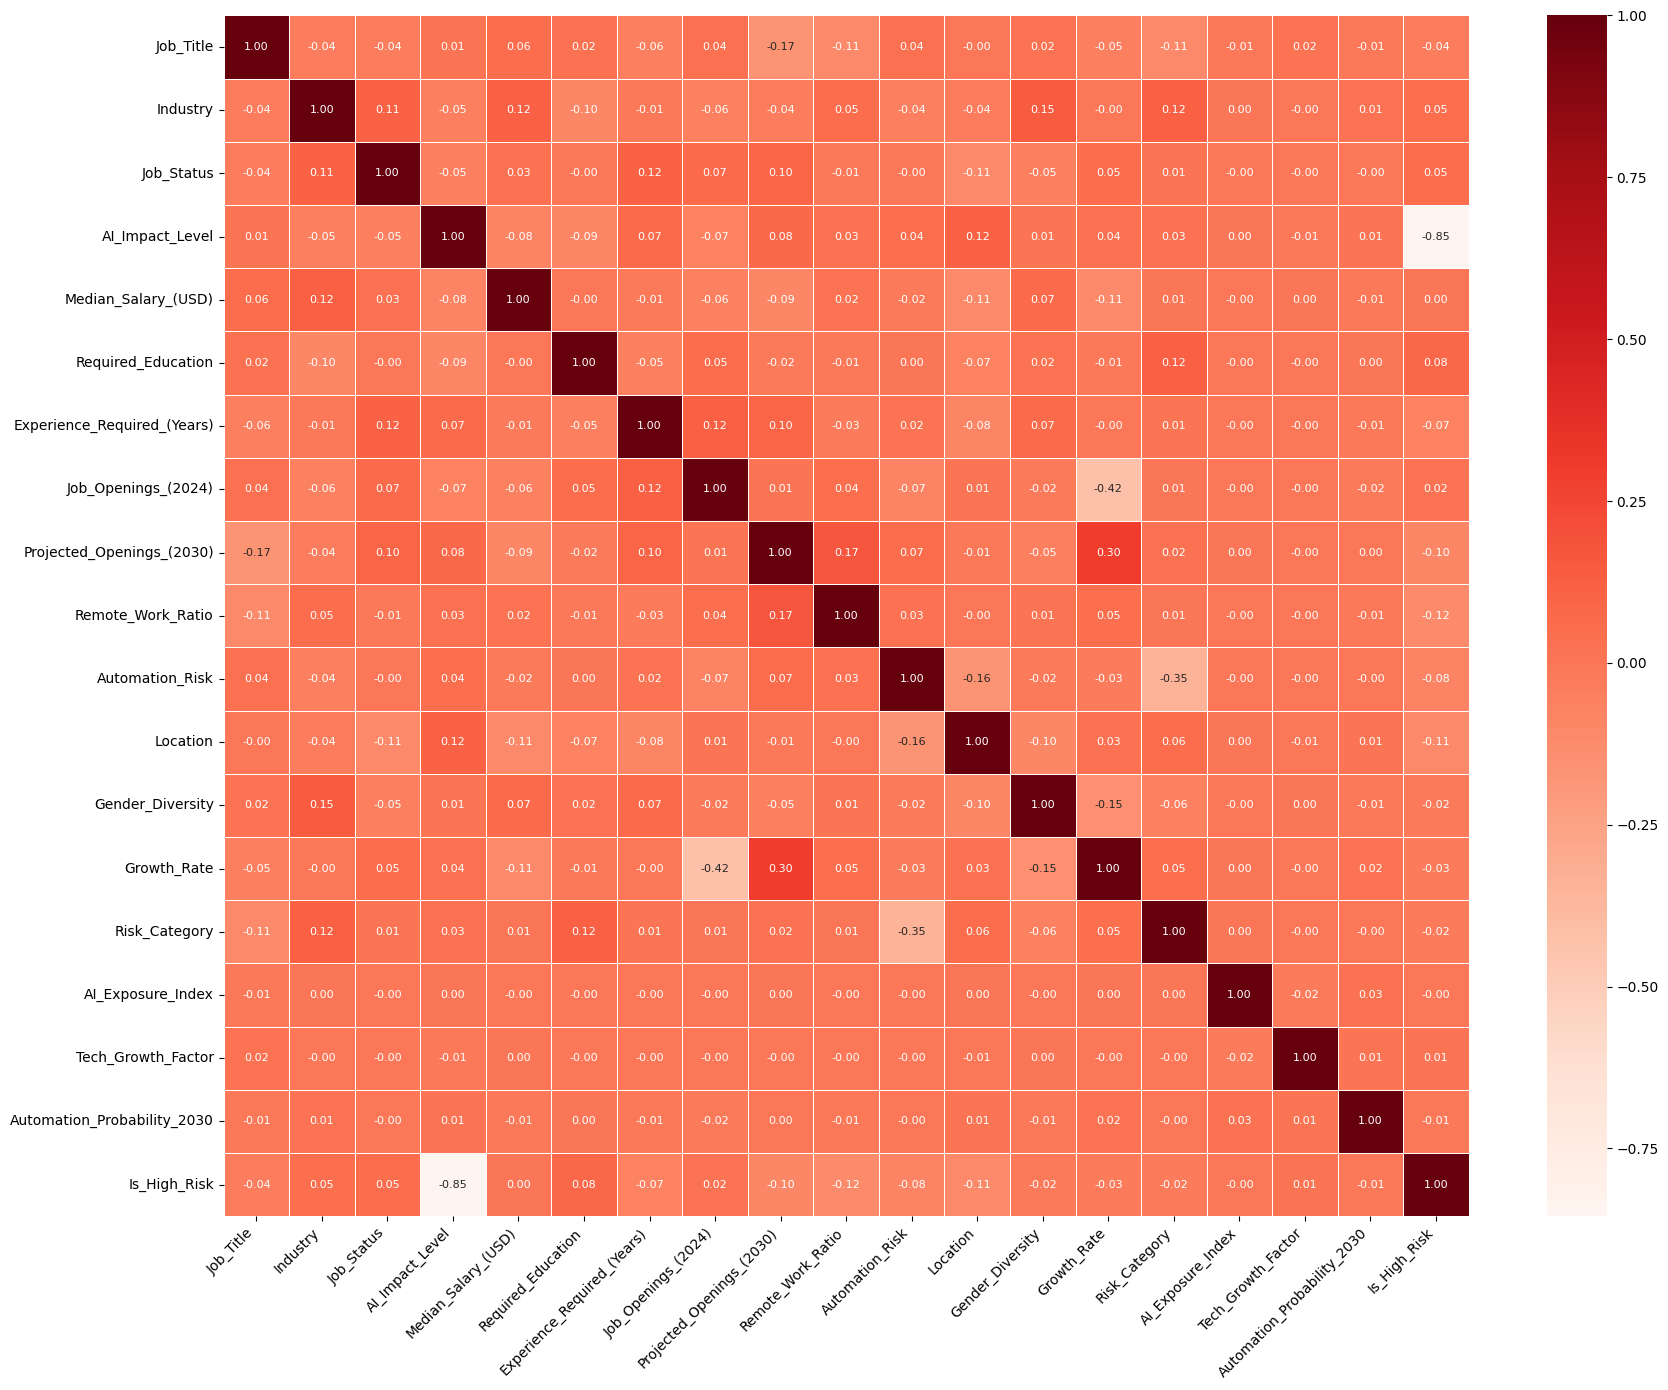

In [26]:
plt.figure(figsize=(18,14))

sns.heatmap(
df.corr(),
annot=True,
fmt=".2f",
cmap="Reds",
linewidths=0.5,
annot_kws={"size":8}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [27]:
suspicious_columns = [
    'Is_High_Risk', 
    'Automation_Risk', 
    'Risk_Category', 
    'Automation_Probability_2030', 
    'AI_Exposure_Index',
]

features = df.drop(columns=['AI_Impact_Level'] + suspicious_columns, errors='ignore')
target = df['AI_Impact_Level']

X_train, X_test, y_train, y_test = train_test_split(features ,target , test_size=0.2, random_state=42)

## Logistic Regression

In [28]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_lr

0.46280125742228434

## Random Forest Model

In [29]:
estimators_to_test = [50, 75, 100, 250, 300 ,400 ,500]

In [30]:
for n in estimators_to_test:
    rf_model = RandomForestClassifier(
        n_estimators=n, 
        max_depth=4, 
        random_state=42, 
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    acc

In [31]:
rf_model = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1 ,max_depth=4)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8774013272790779

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1926
           1       0.85      0.97      0.91      2537
           2       1.00      0.56      0.72      1263

    accuracy                           0.88      5726
   macro avg       0.91      0.83      0.85      5726
weighted avg       0.89      0.88      0.87      5726



/var/folders/3b/rk4wlpz91b550937x0t31krc0000gn/T/ipykernel_3560/3723829137.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='Reds_r')


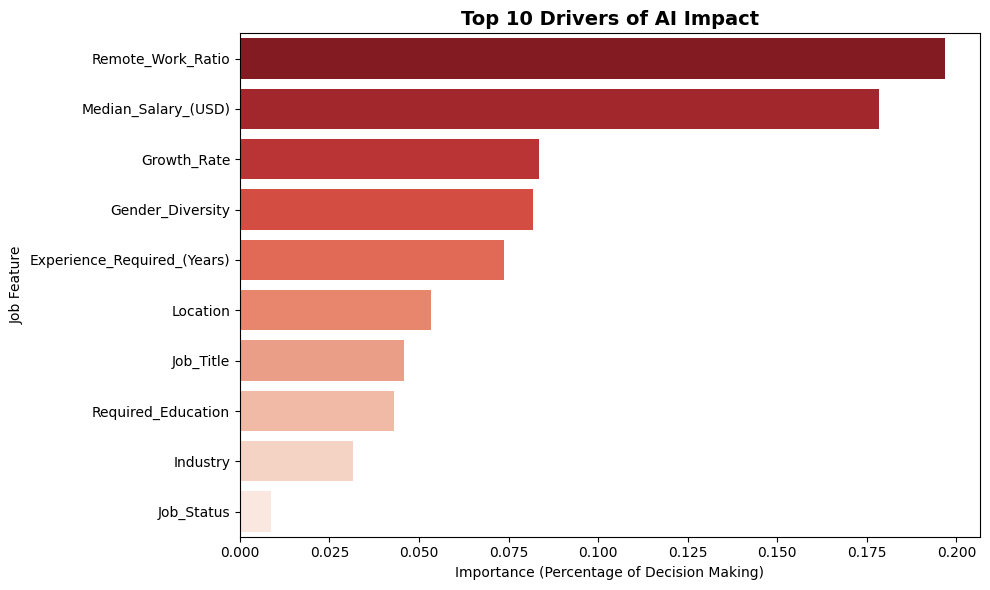

In [33]:

importances = rf_model.feature_importances_

feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
importance_df.drop(index=importance_df[importance_df['Feature'] == 'Projected_Openings_(2030)'].index, inplace=True) 
importance_df.drop(index=importance_df[importance_df['Feature'] == 'Job_Openings_(2024)'].index, inplace=True) 

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='Reds_r')
plt.title('Top 10 Drivers of AI Impact', fontsize=14, fontweight='bold')
plt.xlabel('Importance (Percentage of Decision Making)')
plt.ylabel('Job Feature')
plt.tight_layout()
plt.show()

## XGBoost Classifier

In [34]:
X_train

,Job_Title,Industry,Job_Status,Median_Salary_(USD),Required_Education,Experience_Required_(Years),Job_Openings_(2024),Projected_Openings_(2030),Remote_Work_Ratio,Location,Gender_Diversity,Growth_Rate,Tech_Growth_Factor
6778,3,1,1,-0.809106,3,0.831541,-1.659081,1.623633,-0.795530,3,-1.403547,8.339711,0.463270
12796,3,5,1,0.091056,0,-0.175283,-1.503051,0.724225,0.883359,7,-0.980318,1.137788,1.614076
4724,2,5,0,0.891196,4,0.328129,-1.185777,-1.227646,-0.783533,1,1.594989,-0.257228,-1.315248
17982,1,3,0,0.092899,0,-0.007479,-0.536286,-1.449488,-1.150504,6,-1.106374,-0.345812,-1.489612
15028,3,7,0,-1.087292,1,0.160325,0.483299,-1.387579,-0.289887,2,1.087913,-0.355092,0.916618
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,3,0,0,0.424065,3,-1.182108,-0.578682,-0.652575,1.468748,4,-0.989444,-0.254858,0.358652
5390,2,3,1,1.439732,3,0.160325,-1.513824,0.291890,-0.260953,0,0.949309,0.937723,0.567889
860,3,1,0,1.349782,4,-0.510891,-0.903949,-0.561430,-1.616274,1,1.677125,-0.192406,-1.210629
15795,2,0,0,-1.122830,4,-0.510891,1.672816,-0.197540,0.628950,3,0.259138,-0.316721,1.614076


In [35]:
for n in estimators_to_test:
    xgb_boosting_model = XGBClassifier(n_estimators=n, max_depth=4, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
    xgb_boosting_model.fit(X_train, y_train)
    y_pred_xgb = xgb_boosting_model.predict(X_test)
    acc_xgb = accuracy_score(y_test, y_pred_xgb)
    print(f"XGBoosting Model with {n} Estimators: {acc_xgb}%")

/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:42:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoosting Model with 50 Estimators: 1.0%


/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:42:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoosting Model with 75 Estimators: 1.0%


/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:42:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

XGBoosting Model with 300 Estimators: 1.0%


/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:42:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoosting Model with 400 Estimators: 1.0%


/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:42:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoosting Model with 500 Estimators: 1.0%


In [36]:
xgb_boosting_model = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, eval_metric='mlogloss')
xgb_boosting_model.fit(X_train, y_train)
y_pred_xgb = xgb_boosting_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoosting Model Accuracy: {acc_xgb:.2f}%\n")

XGBoosting Model Accuracy: 1.00%



In [37]:
xgb_boosting_model = XGBClassifier(
    n_estimators=50,      
    max_depth=4,          
    learning_rate=0.05,
    random_state=42, 
    eval_metric='mlogloss'
)
xgb_boosting_model.fit(X_train, y_train)
y_pred_xgb_h = xgb_boosting_model.predict(X_test)
acc_xgb_h = accuracy_score(y_test, y_pred_xgb_h)
acc_xgb_h

0.9505763185469787

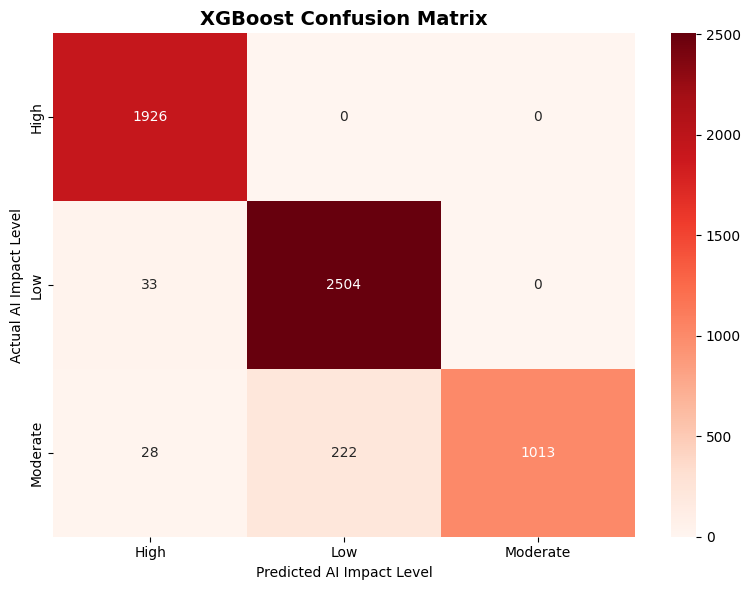

In [41]:
cm = confusion_matrix(y_test, y_pred_xgb_h)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['High', 'Low', 'Moderate'], 
            yticklabels=['High', 'Low', 'Moderate'])
plt.title('XGBoost Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted AI Impact Level')
plt.ylabel('Actual AI Impact Level')
plt.tight_layout()
plt.show()

In [39]:
print(f"Random Forest:{accuracy_score(y_test, y_pred):.2f}")
print(f"XGBoosting before hyperparameter tuning:{acc_xgb:.2f}")
print(f"XGBoosting after hyperparameter tuning:{acc_xgb_h:.2f}")
print(f"Logistic Regression:{acc_lr:.2f}")

Random Forest:0.88
XGBoosting before hyperparameter tuning:1.00
XGBoosting after hyperparameter tuning:0.95
Logistic Regression:0.46


In [42]:
joblib.dump(xgb_boosting_model, '../DataSet/model/xgb_boosting_model.pkl')
print("Champion Model saved successfully for Streamlit!")

Champion Model saved successfully for Streamlit!
